# Feature Extraction


This notebook shows, step by step, how to build a **supervised learning dataset** for time-series forecasting using market data.

### Objectives
- Transform raw prices into informative features.
- Build a clear target variable with a 1-day prediction horizon.
- Avoid leakage by using only past information.
- Perform train/validation/test split with time order.
- Leave data ready for model training in the next notebook.

### What we will build at the end
- A clean DataFrame with engineered features and target.
- Temporal splits: train, validation, and test.
- `X_train`, `y_train`, `X_valid`, `y_valid`, `X_test`, `y_test`.
- Verification plots to confirm feature behavior.

### Key reminder
In forecasting, **temporal validation** is essential, and preventing **leakage** is non-negotiable.


## 1. Preparation and imports

A **DataFrame** is a table with rows and columns.
In finance, each row is usually a date, and columns represent variables such as price, returns, or features.

Why use DataFrames here?
- They keep the full pipeline organized.
- They make transformations easy (rolling windows, shifts, lags).
- They integrate naturally with model inputs (`X`) and outputs (`y`).


In [ ]:
# 2. Imports
# Import core libraries for downloading, transforming, and plotting data.

import importlib.util

# In Colab, install yfinance only if it is not already available.
if importlib.util.find_spec("yfinance") is None:
    !pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Basic plot configuration for readability.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


## 3. Download base data (SPY)

We start with **one main asset (SPY)** to keep the pipeline simple and transparent.

Why `Adj Close`?
- It adjusts for dividends and splits.
- It is usually preferred for return calculations and historical comparability.


In [ ]:
# 4. Download SPY data (2015-01-01 onward)
# Download daily SPY data from Yahoo Finance.

data = yf.download("SPY", start="2015-01-01", auto_adjust=False, progress=False)

# Quick inspection of structure.
data.head()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,167.052597,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.479187,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.541199,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800


## 5. Step 1: build returns

A **return** tells us how much the price changed in relative terms.

- Simple return: easy to interpret in percent-like form.
- Log-return: often useful in advanced modeling.

For clarity in this notebook, we use **simple returns** in the main workflow.


In [ ]:
# 6. Returns
# Create simple daily returns from adjusted close.

data["ret"] = data["Adj Close"].pct_change()

# Show rows after removing initial NaN.
data.dropna().head()


Price,Adj Close,Close,High,Low,Open,Volume,ret
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,,
2015-01-05,167.052597,201.720001,204.369995,201.350006,204.169998,169632600,-0.018060
2015-01-06,165.479187,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419
2015-01-07,167.541199,202.309998,202.720001,200.880005,201.419998,125346700,0.012461
2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800,0.017745
2015-01-09,169.147766,204.250000,206.419998,203.509995,206.399994,158567300,-0.008014


In [ ]:
# 7. Exercise 1 (TODO)
# Task: create a log-return column called 'log_ret'.

data["log_ret"] = np.log(data["Adj Close"]).diff()

data.head()

Price,Adj Close,Close,High,Low,Open,Volume,ret,log_ret
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,NaN,NaN
2015-01-05,167.052597,201.720001,204.369995,201.350006,204.169998,169632600,-0.018060,-0.018225
2015-01-06,165.479187,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419,-0.009463
2015-01-07,167.541199,202.309998,202.720001,200.880005,201.419998,125346700,0.012461,0.012384
2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800,0.017745,0.017589


## 8. Step 2: rolling features (moving averages and volatility)

A **feature** is a predictor variable used by a model.

A **rolling window** means: compute a metric using only the last N observations.

Intuition:
- A 10-day moving average = average of last 10 prices.
- Rolling metrics smooth short-term noise and summarize recent behavior.

Important rule:
- Features must use only present/past data, never future data.


In [ ]:
# 9. Features: moving averages
# Create moving averages on adjusted close.
# These features are backward-looking (past-only information).

data["ma10"] = data["Adj Close"].rolling(window=10).mean()
data["ma30"] = data["Adj Close"].rolling(window=30).mean()

# Inspect key columns.
data[["Adj Close", "ma10", "ma30"]].head(15)


Price,Adj Close,ma10,ma30
Ticker,SPY,,
Date,,,
2015-01-02,170.125015,NaN,NaN
2015-01-05,167.052597,NaN,NaN
2015-01-06,165.479187,NaN,NaN
2015-01-07,167.541199,NaN,NaN
2015-01-08,170.514221,NaN,NaN
2015-01-09,169.147766,NaN,NaN
2015-01-12,167.822784,NaN,NaN
2015-01-13,167.350739,NaN,NaN


In [ ]:
# 10. Exercise 2 (TODO)
# Tasks:
# 1) Create ma50
data["ma50"] = data["Adj Close"].rolling(window=50).mean()

# 2) Create ma100
data["ma100"] = data["Adj Close"].rolling(window=100).mean()

###  viewing
data[["Adj Close", "ma10", "ma30", "ma50", "ma100"]].head()


Price,Adj Close,ma10,ma30,ma50,ma100
Ticker,SPY,,,,
Date,,,,,
2015-01-02,170.125015,NaN,NaN,NaN,NaN
2015-01-05,167.052597,NaN,NaN,NaN,NaN
2015-01-06,165.479187,NaN,NaN,NaN,NaN
2015-01-07,167.541199,NaN,NaN,NaN,NaN
2015-01-08,170.514221,NaN,NaN,NaN,NaN


In [ ]:
# 11. Feature: rolling volatility
# Rolling volatility = standard deviation of returns in a moving window.

data["vol10"] = data["ret"].rolling(window=10).std()
data["vol30"] = data["ret"].rolling(window=30).std()

# Inspect volatility features.
data[["ret", "vol10", "vol30"]].head(35)


Price,ret,vol10,vol30
Ticker,,,
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.018060,NaN,NaN
2015-01-06,-0.009419,NaN,NaN
2015-01-07,0.012461,NaN,NaN
2015-01-08,0.017745,NaN,NaN
2015-01-09,-0.008014,NaN,NaN
2015-01-12,-0.007833,NaN,NaN
2015-01-13,-0.002813,NaN,NaN


In [ ]:
# 12. Exercise 3 (TODO)
# Tasks:
# 1) Create vol60
data["vol60"] = data["ret"].rolling(window=60).std()

# 2) Check how many NaNs appear due to rolling windows
print(data[["vol10", "vol30", "vol60"]].isna().sum())


Price  Ticker
vol10            10
vol30            30
vol60            60
dtype: int64


## 13. Step 3: lags (past values as predictors)

A **lag** means a shifted past value of a variable.

Examples:
- Lag 1 = yesterday's value.
- Lag 2 = value two days ago.

Why include lags?
- They provide short memory to the model.
- They are standard baseline predictors in time-series tasks.


In [ ]:
# 14. Create lags
# Create lagged returns to represent recent historical behavior.

data["lag_ret_1"] = data["ret"].shift(1)
data["lag_ret_2"] = data["ret"].shift(2)
data["lag_ret_5"] = data["ret"].shift(5)

# Preview lag columns.
data[["ret", "lag_ret_1", "lag_ret_2", "lag_ret_5"]].head(10)


Price,ret,lag_ret_1,lag_ret_2,lag_ret_5
Ticker,,,,
Date,,,,
2015-01-02,NaN,NaN,NaN,NaN
2015-01-05,-0.018060,NaN,NaN,NaN
2015-01-06,-0.009419,-0.018060,NaN,NaN
2015-01-07,0.012461,-0.009419,-0.018060,NaN
2015-01-08,0.017745,0.012461,-0.009419,NaN
2015-01-09,-0.008014,0.017745,0.012461,NaN
2015-01-12,-0.007833,-0.008014,0.017745,-0.018060
2015-01-13,-0.002813,-0.007833,-0.008014,-0.009419


In [ ]:
# 15. Exercise 4 (TODO)
# Tasks:
# 1) Create lag_ret_10
data["lag_ret_10"] = data["ret"].shift(10)

# 2) Create lag_price_1 = Adj Close.shift(1)
data["lag_price_1"] = data["Adj Close"].shift(1)


### viewing
data[["ret", "lag_ret_10", "Adj Close", "lag_price_1"]].head()


Price,ret,lag_ret_10,Adj Close,lag_price_1
Ticker,,,SPY,
Date,,,,
2015-01-02,NaN,NaN,170.125015,NaN
2015-01-05,-0.018060,NaN,167.052597,170.125015
2015-01-06,-0.009419,NaN,165.479187,167.052597
2015-01-07,0.012461,NaN,167.541199,165.479187
2015-01-08,0.017745,NaN,170.514221,167.541199


## 16. Step 4: create the target (what we want to predict)

The **target** is the variable the model should predict.

Here we use a **1-day horizon**:
- Predict tomorrow's return with today's and past features.

How `shift(-1)` works:
- It moves the return column one row upward.
- Row at date *t* receives return from date *t+1*.


In [ ]:
# 17. Create target
# Target = next-day simple return.

data["target"] = data["ret"].shift(-1)

# Quick check.
data[["ret", "target"]].head(10)


Price,ret,target
Ticker,,
Date,,
2015-01-02,NaN,-0.018060
2015-01-05,-0.018060,-0.009419
2015-01-06,-0.009419,0.012461
2015-01-07,0.012461,0.017745
2015-01-08,0.017745,-0.008014
2015-01-09,-0.008014,-0.007833
2015-01-12,-0.007833,-0.002813
2015-01-13,-0.002813,-0.006037


## 18. Final cleaning and column selection

NaNs appear for expected reasons:
- First return is NaN (no previous observation).
- Rolling features need enough history.
- Lags create NaNs at the beginning.
- Target with `shift(-1)` creates NaN at the final row.

We build a final modeling DataFrame by selecting columns and applying `dropna()`.


In [ ]:
# 19. Select features and clean NaNs
# Define the baseline feature set.

feature_cols = [
    "ret",
    "ma10",
    "ma30",
    "vol10",
    "vol30",
    "lag_ret_1",
    "lag_ret_2",
    "lag_ret_5",
]

# Create final modeling DataFrame and remove incomplete rows.
df = data[feature_cols + ["target"]].dropna().copy()

# Inspect result.
df.head()


Price,ret,ma10,ma30,vol10,vol30,lag_ret_1,lag_ret_2,lag_ret_5,target
Ticker,,,,,,,,,
Date,,,,,,,,,
2015-02-17,0.001573,171.238864,168.827308,0.006820,0.009987,0.004116,0.009617,-0.004476,0.000095
2015-02-18,0.000095,171.676953,169.059464,0.005811,0.009334,0.001573,0.004116,0.010654,-0.000714
2015-02-19,-0.000714,172.167213,169.339926,0.005508,0.009119,0.000095,0.001573,0.000580,0.006001
2015-02-20,0.006001,172.591220,169.586436,0.005045,0.008930,-0.000714,0.000095,0.009617,-0.000142
2015-02-23,-0.000142,173.059949,169.733017,0.004805,0.008387,0.006001,-0.000714,0.004116,0.002841


In [ ]:
# 20. Exercise 5 (TODO)
# Task: add 'day_of_week' (0-4) using the datetime index.
# Hint: df.index.dayofweek

df["day_of_week"] = df.index.dayofweek

df.head()

Price,ret,ma10,ma30,vol10,vol30,lag_ret_1,lag_ret_2,lag_ret_5,target,day_of_week
Ticker,,,,,,,,,,
Date,,,,,,,,,,
2015-02-17,0.001573,171.238864,168.827308,0.006820,0.009987,0.004116,0.009617,-0.004476,0.000095,1
2015-02-18,0.000095,171.676953,169.059464,0.005811,0.009334,0.001573,0.004116,0.010654,-0.000714,2
2015-02-19,-0.000714,172.167213,169.339926,0.005508,0.009119,0.000095,0.001573,0.000580,0.006001,3
2015-02-20,0.006001,172.591220,169.586436,0.005045,0.008930,-0.000714,0.000095,0.009617,-0.000142,4
2015-02-23,-0.000142,173.059949,169.733017,0.004805,0.008387,0.006001,-0.000714,0.004116,0.002841,0


## 21. Step 5: temporal split (train/valid/test)

Why we should NOT use random split:
- Random split mixes past and future.
- This can create leakage and unrealistic validation metrics.

Temporal split example:
- Train: 2015-2020
- Validation: 2021
- Test: 2022 onward


In [ ]:
# 22. Temporal split
# Split by date ranges to preserve chronological order.

train_df = df.loc[:"2020-12-31"].copy()
valid_df = df.loc["2021-01-01":"2021-12-31"].copy()
test_df = df.loc["2022-01-01":].copy()

print("Train period:", train_df.index.min(), "->", train_df.index.max())
print("Validation period:", valid_df.index.min(), "->", valid_df.index.max())
print("Test period:", test_df.index.min(), "->", test_df.index.max())


Train period: 2015-02-17 00:00:00 -> 2020-12-31 00:00:00
Validation period: 2021-01-04 00:00:00 -> 2021-12-31 00:00:00
Test period: 2022-01-03 00:00:00 -> 2026-03-26 00:00:00


In [ ]:
# 23. Separate X and y
# X contains features; y contains the target.

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_valid = valid_df[feature_cols]
y_valid = valid_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("Feature matrices and target vectors are ready.")


Feature matrices and target vectors are ready.


In [ ]:
# 24. Exercise 6 (TODO)
# Tasks:
# 1) Print shapes of all X/y splits
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# 2) Check there are no NaNs in X_train
print("NaNs in X_train:", X_train.isna().sum().sum())


X_train: (1481, 8)
y_train: (1481,)
X_valid: (252, 8)
y_valid: (252,)
X_test: (1061, 8)
y_test: (1061,)
NaNs in X_train: 0


## 25. Verification visualizations (very important)

These plots are diagnostic checks:
- They confirm that engineered features behave as expected.
- They help detect obvious mistakes before model training.

Visual inspection is a practical quality-control step in forecasting pipelines.


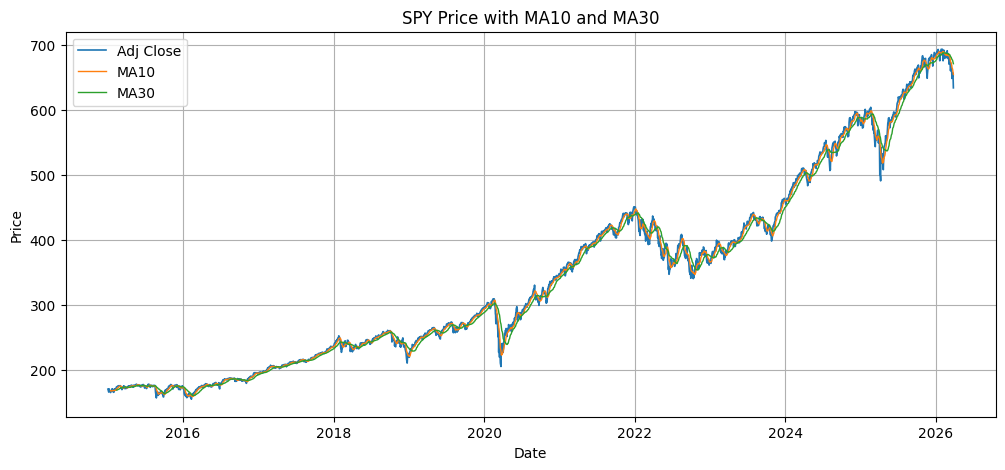

In [ ]:
# 26. Plot 1: Adj Close + ma10 + ma30
# Visual check of price and moving-average features.

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Adj Close"], label="Adj Close", linewidth=1.2)
plt.plot(data.index, data["ma10"], label="MA10", linewidth=1.0)
plt.plot(data.index, data["ma30"], label="MA30", linewidth=1.0)
plt.title("SPY Price with MA10 and MA30")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


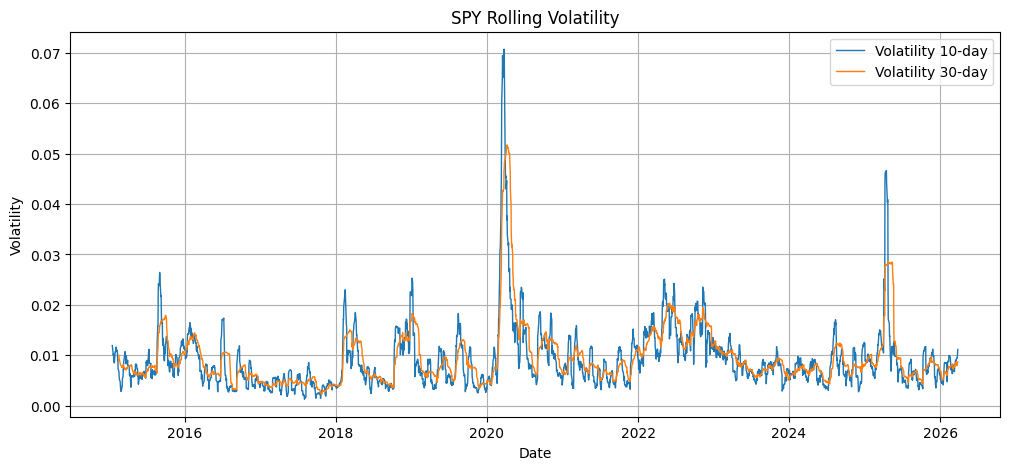

In [ ]:
# 27. Plot 2: rolling volatility (vol10, vol30)
# Visual check of short and medium rolling volatility.

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["vol10"], label="Volatility 10-day", linewidth=1.0)
plt.plot(data.index, data["vol30"], label="Volatility 30-day", linewidth=1.0)
plt.title("SPY Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()


## 28. Final mini-project (large exercise)

### Task
Build your own end-to-end supervised dataset pipeline for a ticker of your choice.

If you do not choose one, use **AAPL** by default.

### Checklist (use this to self-validate)
- [ ] Choose a ticker (or a small ticker list).
- [ ] Download data from a stable start date.
- [ ] Create simple returns.
- [ ] Create at least **5 features**.
- [ ] Include at least **2 rolling features**.
- [ ] Include at least **2 lag features**.
- [ ] Include at least **1 additional feature** (for example day-of-week or lagged volatility).
- [ ] Create target with `shift(-1)`.
- [ ] Apply temporal split.
- [ ] Build `X_train`, `y_train`, `X_test`, `y_test`.
- [ ] Create at least 2 verification plots.
- [ ] Print a summary table with mean return and volatility.
- [ ] Keep `df_final` ready for model training.

Optional extension: compare your main ticker to AAPL with one normalized-price chart.


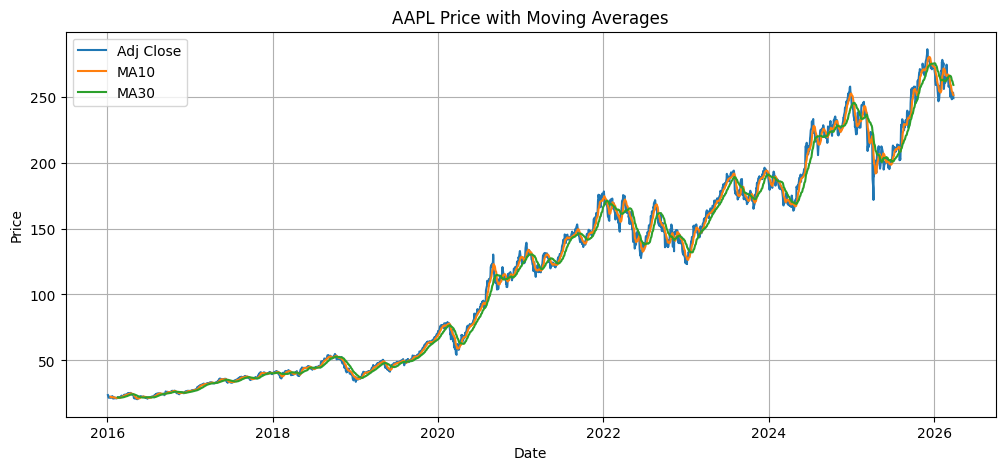

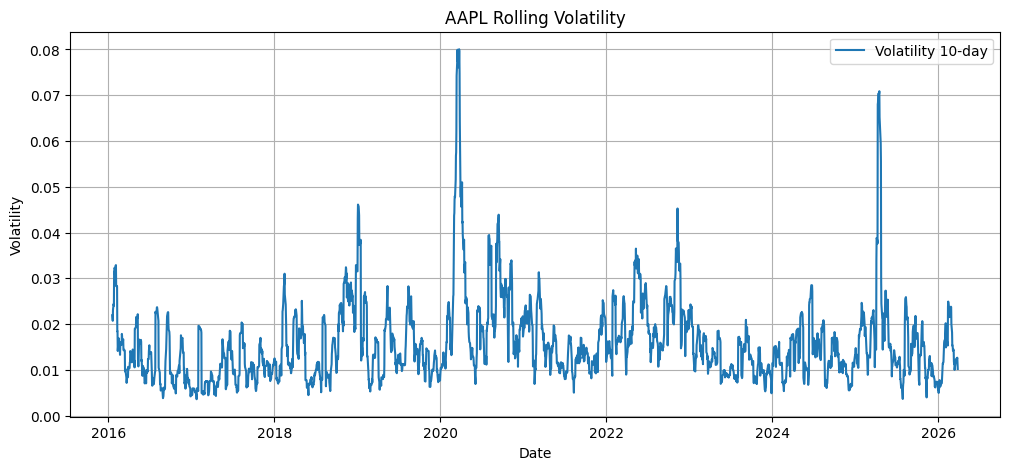

      mean_ret   vol_ret
AAPL   0.00108  0.018242


In [ ]:
# 29. Mini-project template (TODO)
# Complete each block to build your own forecasting-ready dataset.

# TODO
ticker = "AAPL"

# TODO
mini = yf.download(ticker, start="2016-01-01", auto_adjust=False, progress=False)

# TODO
mini["ret"] = mini["Adj Close"].pct_change()

# TODO
mini["ma10"] = mini["Adj Close"].rolling(window=10).mean()
mini["ma30"] = mini["Adj Close"].rolling(window=30).mean()
mini["vol10"] = mini["ret"].rolling(window=10).std()
mini["lag_ret_1"] = mini["ret"].shift(1)
mini["lag_ret_5"] = mini["ret"].shift(5)
mini["day_of_week"] = mini.index.dayofweek

# TODO
mini["target"] = mini["ret"].shift(-1)

# TODO
feature_cols_mini = [
    "ret",
    "ma10",
    "ma30",
    "vol10",
    "lag_ret_1",
    "lag_ret_5",
    "day_of_week",
]

df_final = mini[feature_cols_mini + ["target"]].dropna().copy()

# TODO
train_mini = df_final.loc[:"2020-12-31"]
test_mini = df_final.loc["2021-01-01":]

# TODO
X_train = train_mini[feature_cols_mini]
y_train = train_mini["target"]
X_test = test_mini[feature_cols_mini]
y_test = test_mini["target"]

# TODO
# 1) price with moving averages
plt.figure(figsize=(12, 5))
plt.plot(mini.index, mini["Adj Close"], label="Adj Close")
plt.plot(mini.index, mini["ma10"], label="MA10")
plt.plot(mini.index, mini["ma30"], label="MA30")
plt.title(f"{ticker} Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# 2) rolling volatility or return histogram
plt.figure(figsize=(12, 5))
plt.plot(mini.index, mini["vol10"], label="Volatility 10-day")
plt.title(f"{ticker} Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

# TODO
# summary
summary = pd.DataFrame({
    "mean_ret": [mini["ret"].mean()],
    "vol_ret": [mini["ret"].std()]
}, index=[ticker])

print(summary)